# Energy Model Calibration (DESNZ vs ABM)

Self-contained calibration: load ABM outputs, load DESNZ LSOA elec+gas, compare per-dwelling (ABM per UPRN) to DESNZ per-meter, and plot distributions by year.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# display options
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 50)


In [2]:
# Ensure notebook imports local repo code with fuel-split reporters
import sys
import importlib
import inspect
from pathlib import Path

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import household_energy.model as he_model
import household_energy.run_lsoa_batch as he_batch

importlib.reload(he_model)
importlib.reload(he_batch)

model_src = inspect.getsource(he_model.EnergyModel)
assert 'total_electric_kwh' in model_src and 'total_gas_kwh' in model_src, (
    'Loaded EnergyModel does not include fuel-split reporters; restart kernel and verify PYTHONPATH.'
)
print('Using local module:', Path(he_model.__file__).resolve())


Using local module: /Users/abeltran/Documents/GitHub/spdt_abm/household_energy/model.py


## Paths and settings
Edit these as needed. `RUN_MODEL` defaults to False (use existing outputs).

In [3]:
# Data paths (relative to repo root)
GEOJSON     = Path('../data/epc_abm_waltham_forest.geojson')
CLIMATE     = Path('../data/waltham_forest_2t_timeseries_2010_2026.parquet')
HIDP_CSV    = Path('../data/wf_hidp_uprn_matches_tiered.csv')
ELEC_XLSX   = Path('../data/LSOA_domestic_elec_2010-2024.xlsx')
GAS_XLSX    = Path('../data/LSOA_domestic_gas_2010-2024.xlsx')
CONFIG_PATH = Path('../configs/wf_best.yaml')
# Gas spike share overrides (used by config, if set there)
OUTDIR      = Path('results/calibration_wf')
OUTDIR.mkdir(parents=True, exist_ok=True)

# Model outputs (produced separately via run.py)
MODEL_PARQUET = OUTDIR / 'model_timeseries.parquet'
AGENT_PARQUET = OUTDIR / 'agent_timeseries.parquet'

RUN_MODEL = False           # set True to rerun long model here (slow)
START_UTC = '2020-01-01T00:00:00Z'
END_UTC   = '2025-01-01T00:00:00Z'
YEARS = [2020, 2021, 2022, 2023, 2024]
LSOA_COL = 'lsoa_code'


## Load GeoJSON + HIDP enrichment (coalesce duplicate area codes)

In [4]:
gdf = gpd.read_file(GEOJSON)
print(f"Loaded {len(gdf):,} dwellings from {GEOJSON}")

# ensure UPRN
if 'UPRN' not in gdf.columns:
    for alt in ['uprn','fid']:
        if alt in gdf.columns:
            gdf['UPRN'] = gdf[alt]
            break
assert 'UPRN' in gdf.columns, 'No UPRN field found.'
gdf['UPRN'] = gdf['UPRN'].astype(str).str.strip()

# HIDP merge (optional)
if HIDP_CSV.exists():
    hidp_df = pd.read_csv(HIDP_CSV, low_memory=False)
    hidp_df.columns = [c.strip() for c in hidp_df.columns]
    hidp_df['uprn_chr'] = hidp_df['uprn_chr'].astype(str).str.strip()
    hidp_df = hidp_df.drop_duplicates('uprn_chr')
    before = len(gdf)
    gdf = gdf.merge(hidp_df, how='left', left_on='UPRN', right_on='uprn_chr', suffixes=('_geo','_hidp'))
    print(f"Merged HIDP: {before:,} -> {len(gdf):,}; unmatched: {gdf['uprn_chr'].isna().sum():,}")
    # coalesce lsoa if duplicated
    if 'lsoa_code_geo' in gdf.columns or 'lsoa_code_hidp' in gdf.columns:
        gdf['lsoa_code'] = gdf.get('lsoa_code_geo').combine_first(gdf.get('lsoa_code_hidp'))
        gdf.drop(columns=[c for c in ['lsoa_code_geo','lsoa_code_hidp'] if c in gdf.columns], inplace=True)
else:
    print('Skipping HIDP enrichment (file not found)')

assert LSOA_COL in gdf.columns, f"{LSOA_COL} not found after merge"


Loaded 84,755 dwellings from ../data/epc_abm_waltham_forest.geojson
Merged HIDP: 84,755 -> 84,755; unmatched: 2,863


## Optional: run model (slow) or load existing outputs
If `RUN_MODEL=False`, ensure `model_timeseries.parquet` and `agent_timeseries.parquet` exist in OUTDIR.


## Optional: run per-LSOA batch (ABM → annual per-dwelling)

In [5]:
# Toggle to run per-LSOA batch simulations (writes to results_lsoa_wf)
RUN_LSOA_BATCH = True
LSOA_BATCH_CODES = None  # e.g., ['E01035614', 'E01008358']; None = all LSOAs in GEOJSON
LSOA_BATCH_OUTDIR = Path('results_lsoa_wf')
LSOA_BATCH_MAX_PROCS = 6

In [6]:
# Convenience: pick the largest 20 LSOAs by dwelling count for quick tests
FILTER_TOP20_LSOA = True

if 'FILTER_TOP20_LSOA' not in globals():
    FILTER_TOP20_LSOA = False
if FILTER_TOP20_LSOA:
    lsoa_counts = gdf.groupby(LSOA_COL)['UPRN'].nunique().sort_values(ascending=False)
    LSOA_BATCH_CODES = list(lsoa_counts.head(20).index)
    print(f"Selected top {len(LSOA_BATCH_CODES)} LSOAs by dwellings: {LSOA_BATCH_CODES[:5]}...")


Selected top 20 LSOAs by dwellings: ['E01004444', 'E01034486', 'E01004430', 'E01004404', 'E01004348']...


In [7]:
import multiprocessing as mp
from household_energy.run_lsoa_batch import RunConfig, _run_single_lsoa


def run_lsoa_batch(lsoas=None, max_procs=LSOA_BATCH_MAX_PROCS):
    stamp = pd.Timestamp.utcnow().strftime('%Y%m%d')
    cfg = RunConfig(
        geojson=GEOJSON,
        climate=CLIMATE,
        hidp_csv=HIDP_CSV if HIDP_CSV.exists() else None,
        config_path=CONFIG_PATH if CONFIG_PATH.exists() else None,
        start_utc=START_UTC,
        end_utc=END_UTC,
        days=None,
        local_tz='Europe/London',
        lsoa_col=LSOA_COL,
        outdir=LSOA_BATCH_OUTDIR,
        agent_collect_every=1,
        save_model_timeseries=False,
        stamp=stamp,
    )

    gdf_all = gpd.read_file(GEOJSON)
    if LSOA_COL not in gdf_all.columns:
        geo_col = f"{LSOA_COL}_geo"
        hidp_col = f"{LSOA_COL}_hidp"
        if geo_col in gdf_all.columns or hidp_col in gdf_all.columns:
            if geo_col in gdf_all.columns and hidp_col in gdf_all.columns:
                gdf_all[LSOA_COL] = gdf_all[geo_col].combine_first(gdf_all[hidp_col])
            elif geo_col in gdf_all.columns:
                gdf_all[LSOA_COL] = gdf_all[geo_col]
            else:
                gdf_all[LSOA_COL] = gdf_all[hidp_col]
    if LSOA_COL not in gdf_all.columns:
        raise KeyError(f"{LSOA_COL} not found in {GEOJSON}")

    all_lsoas = sorted(gdf_all[LSOA_COL].astype(str).unique())
    target_lsoas = list(lsoas) if lsoas is not None else list(all_lsoas)
    total = len(target_lsoas)
    print(f"Running {total} LSOAs → {cfg.outdir} (stamp {stamp})")
    cfg.outdir.mkdir(parents=True, exist_ok=True)

    tasks = [(lsoa, cfg, i + 1, total) for i, lsoa in enumerate(target_lsoas)]
    if max_procs == 1:
        rows = [_run_single_lsoa(*task) for task in tasks]
    else:
        try:
            with mp.Pool(processes=max(1, max_procs)) as pool:
                rows = pool.starmap(_run_single_lsoa, tasks)
        except RuntimeError as e:
            print(f"Pool failed ({e}); falling back to serial.")
            rows = [_run_single_lsoa(*task) for task in tasks]

    annual_all = pd.concat([r for r in rows if r is not None], ignore_index=True)
    if not annual_all.empty:
        stamp_path = cfg.outdir / f"abm_year_all_{stamp}.parquet"
        annual_all.to_parquet(stamp_path, index=False)
        annual_all.to_csv(cfg.outdir / f"abm_year_all_{stamp}.csv", index=False)
        print(f"Saved combined annual table → {stamp_path.name}")
    return annual_all


## Load DESNZ LSOA data (elec + gas)

In [8]:

import re

NORM_COLMAP = {
    "Local authority code": "la_code",
    "Local authority": "local_authority",
    "MSOA code": "msoa_code",
    "Middle layer super output area": "msoa_name",
    "LSOA code": "lsoa_code",
    "Lower layer super output area": "lsoa_name",
    "Number of meters": "meters",
    "Total consumption (kWh)": "total_kwh",
    "Mean consumption (kWh per meter)": "mean_kwh",
    "Median consumption (kWh per meter)": "median_kwh",
}

def tidy_lsoa(xlsx_path: Path, fuel: str) -> pd.DataFrame:
    book = pd.read_excel(xlsx_path, sheet_name=None, header=4, engine="openpyxl")
    # drop first sheet (notes)
    first = next(iter(book))
    book.pop(first, None)
    frames = []
    for sheet_name, df in book.items():
        df = df.copy()

        df.columns = df.columns.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        df = df.rename(columns={k: v for k, v in NORM_COLMAP.items() if k in df.columns})
        wanted = [
            "lsoa_code",
            "lsoa_name",
            "meters",
            "total_kwh",
            "mean_kwh",
            "median_kwh",
        ]
        keep = [c for c in wanted if c in df.columns]
        if not keep:
            continue
        df = df[keep].copy()
        for c in {"meters", "total_kwh", "mean_kwh", "median_kwh"} & set(keep):
            df[c] = pd.to_numeric(
                df[c].astype(str).str.replace(',', '', regex=False),
                errors="coerce",
            )
        m = re.search(r"(20\d{2})", str(sheet_name))
        if not m:
            continue
        df["year"] = int(m.group(1))
        df["fuel"] = fuel
        # --- normalize key fields (CRITICAL) ---
        df["lsoa_code"] = (
            df["lsoa_code"]
            .astype(str)
            .str.replace("\u00a0", " ", regex=False)  # NBSP -> space
            .str.strip()
        )
        # drop junk / unallocated rows
        df = df[df["lsoa_code"].str.match(r"^E\d{8}$", na=False)]
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=["year","fuel","lsoa_code","lsoa_name","meters","total_kwh","mean_kwh","median_kwh"])
    out = pd.concat(frames, ignore_index=True)
    out = out[out["year"].isin(YEARS)]
    return out[["year","fuel","lsoa_code","lsoa_name","meters","total_kwh","mean_kwh","median_kwh"]]

desnz_elec = tidy_lsoa(ELEC_XLSX, "elec")
desnz_gas  = tidy_lsoa(GAS_XLSX,  "gas")
print(f"DESNZ elec rows: {len(desnz_elec):,}; gas rows: {len(desnz_gas):,}")


DESNZ elec rows: 168,775; gas rows: 168,775


## DESNZ per-LSOA per-year (elec+gas / elec meters)

In [9]:

# DESNZ processing: keep mean/median, sum totals, denominator = max(elec_meters, gas_meters)
desnz_long = pd.concat([desnz_elec, desnz_gas], ignore_index=True)

fuel_stats = (
    desnz_long
      .pivot_table(
          index=[LSOA_COL, "year"],
          columns="fuel",
          values=["meters", "total_kwh", "mean_kwh", "median_kwh"],
          aggfunc="first"  # DESNZ already aggregated
      )
)

fuel_stats.columns = [f"{v}_{f}" for v, f in fuel_stats.columns]
fuel_stats = fuel_stats.reset_index()

desnz_tot = fuel_stats.copy()

# Total consumption (electricity + gas)
desnz_tot["desnz_kwh"] = (
    desnz_tot[["total_kwh_elec", "total_kwh_gas"]]
    .sum(axis=1, min_count=1)
)

# Keep both meter counts
desnz_tot["elec_meters"] = desnz_tot["meters_elec"]
desnz_tot["gas_meters"]  = desnz_tot["meters_gas"]

# Dwelling proxy = max of the two
desnz_tot["dwelling_meters"] = (
    desnz_tot[["elec_meters", "gas_meters"]].max(axis=1)
)

# PRIMARY comparator: total kWh per dwelling
desnz_tot["desnz_mean_kwh_per_dw"] = (
    desnz_tot["desnz_kwh"] / desnz_tot["dwelling_meters"]
)

# Diagnostic: reconstructed mean from DESNZ means (weighted by meters)
desnz_tot["desnz_mean_kwh_weighted"] = (
      desnz_tot["mean_kwh_elec"] * desnz_tot["elec_meters"]
    + desnz_tot["mean_kwh_gas"]  * desnz_tot["gas_meters"]
) / desnz_tot["dwelling_meters"]


In [10]:

# Fuel coverage checks
fuels = (
    desnz_long.groupby(["lsoa_code","year"])["fuel"]
              .nunique()
              .reset_index(name="n_fuels")
)

print("LSOA-years with only one fuel present (should be near zero):")
display(fuels.query("n_fuels < 2").head(50))

print("Example rows where a fuel is missing (if any):")
display(
    desnz_long.merge(fuels.query("n_fuels < 2"), on=["lsoa_code","year"], how="inner")
              .sort_values(["lsoa_code","year","fuel"])
              .head(20)
)


LSOA-years with only one fuel present (should be near zero):


,lsoa_code,year,n_fuels


Example rows where a fuel is missing (if any):


,year,fuel,lsoa_code,lsoa_name,meters,total_kwh,mean_kwh,median_kwh,n_fuels


## ABM batch results (per-LSOA runs)

In [11]:
from pathlib import Path

# Load latest ABM batch rollup (run batch if missing)
rollups = sorted(LSOA_BATCH_OUTDIR.glob('abm_year_all_*.parquet'))
if not rollups:
    if RUN_LSOA_BATCH:
        print('No rollups found; running batch now...')
        abm_year_batch = run_lsoa_batch(LSOA_BATCH_CODES, max_procs=LSOA_BATCH_MAX_PROCS)
        rollups = sorted(LSOA_BATCH_OUTDIR.glob('abm_year_all_*.parquet'))
    else:
        raise FileNotFoundError('No abm_year_all_<stamp>.parquet in results_lsoa_wf. Set RUN_LSOA_BATCH=True and re-run.')

if not rollups:
    raise FileNotFoundError('Batch run completed but no rollups were written.')

abm_path = rollups[-1]
abm_batch = pd.read_parquet(abm_path)
if 'run_dwellings' not in abm_batch.columns:
    abm_batch['run_dwellings'] = abm_batch['abm_kwh'] / abm_batch['abm_kwh_per_dw']
for c in ['run_gas_dwellings', 'run_electric_dwellings', 'run_other_dwellings', 'abm_gas_kwh_per_gas_dw']:
    if c not in abm_batch.columns:
        abm_batch[c] = pd.NA
print(f"Loaded ABM batch: {abm_path.name} ({len(abm_batch):,} rows)")


Loaded ABM batch: abm_year_all_20260210.parquet (100 rows)


## Combine and analyze

In [12]:

# Combine ABM batch with DESNZ and summarize
merge_cols = [
    LSOA_COL, "year",
    "desnz_kwh",
    "elec_meters", "gas_meters", "dwelling_meters",
    "desnz_mean_kwh_per_dw",
    "mean_kwh_elec", "median_kwh_elec",
    "mean_kwh_gas", "median_kwh_gas",
    "desnz_mean_kwh_weighted",
]

cmp = abm_batch.merge(
    desnz_tot[merge_cols],
    on=[LSOA_COL,'year'],
    how='inner'
)
cmp = cmp[cmp['year'].isin(YEARS)].copy()
cmp['ratio'] = cmp['abm_kwh_per_dw'] / cmp['desnz_mean_kwh_per_dw']
# Decompose per-dwelling ratio into (total ratio) × (coverage ratio)
cmp['ratio_total'] = cmp['abm_kwh'] / cmp['desnz_kwh']
cmp['coverage_dw'] = cmp['dwelling_meters'] / cmp['run_dwellings']
cmp['ratio_recon'] = cmp['ratio_total'] * cmp['coverage_dw']

# Sanity checks
assert (cmp["dwelling_meters"] > 0).all()
print("Gas meters > elec meters counts:")
display(
    cmp.assign(gas_gt_elec=lambda d: d["gas_meters"] > d["elec_meters"])
       .groupby("gas_gt_elec")[LSOA_COL]
       .count()
)

print(f"Rows: {len(cmp):,} across {cmp[LSOA_COL].nunique()} LSOAs")

# Summary stats by year
summary = cmp.groupby('year').agg(
    n=('ratio','count'),
    mape=('ratio', lambda s: (s.sub(1).abs()).mean()*100),
    median_ratio=('ratio','median'),
    mean_ratio=('ratio','mean')
)
display(summary.style.format({'mape':'{:.1f}%','median_ratio':'{:.3f}','mean_ratio':'{:.3f}'}).set_caption('ABM vs DESNZ per dwelling (max meters denominator)'))


Gas meters > elec meters counts:


gas_gt_elec
False    100
Name: lsoa_code, dtype: int64

Rows: 100 across 20 LSOAs


,n,mape,median_ratio,mean_ratio
year,,,,
2020,20,45.8%,0.638,0.790
2021,20,41.5%,0.696,0.875
2022,20,35.8%,0.712,0.868
2023,20,32.8%,0.755,0.873
2024,20,31.0%,0.798,0.891


### Fuel-split validation
Validate fuel totals using comparable denominators (meter-normalized). In particular, compare ABM electricity totals against DESNZ `mean_kwh_elec × elec_meters` and ABM gas totals against DESNZ `mean_kwh_gas × gas_meters`.

In [13]:
# Fuel totals normalized by meter counts (if available)

if {'abm_elec_kwh', 'mean_kwh_elec', 'elec_meters'}.issubset(cmp.columns):
    denom = cmp['mean_kwh_elec'] * cmp['elec_meters']
    cmp['ratio_elec_total'] = (cmp['abm_elec_kwh'] / denom).where(denom > 0)
if {'abm_gas_kwh', 'mean_kwh_gas', 'gas_meters'}.issubset(cmp.columns):
    denom = cmp['mean_kwh_gas'] * cmp['gas_meters']
    cmp['ratio_gas_total'] = (cmp['abm_gas_kwh'] / denom).where(denom > 0)

cols = [c for c in ['ratio', 'ratio_elec_total', 'ratio_gas_total'] if c in cmp.columns]
if cols:
    display(cmp.groupby('year')[cols].agg(['mean', 'median']))


ratio           ratio_elec_total           ratio_gas_total          
          mean    median             mean    median            mean    median
year                                                                         
2020  0.790264  0.637649         0.736865  0.669855        0.514226  0.508322
2021  0.875255  0.696383         0.747908  0.736658        0.569306  0.552053
2022  0.867677  0.712250         0.759294  0.752038        0.578096  0.559216
2023  0.872858  0.755058         0.730847  0.759437        0.588920  0.570688
2024  0.891267  0.797882         0.708483  0.715237        0.592312  0.574540

In [14]:
cmp.columns

Index(['year', 'abm_kwh', 'abm_elec_kwh', 'abm_gas_kwh', 'abm_other_kwh',
       'lsoa_code', 'run_dwellings', 'run_gas_dwellings',
       'run_off_gas_dwellings', 'run_unknown_gas_connection_dwellings',
       'run_gas_heated_dwellings', 'run_electric_heated_dwellings',
       'run_other_heated_dwellings', 'run_electric_dwellings',
       'run_other_dwellings', 'abm_kwh_per_dw', 'abm_elec_kwh_per_dw',
       'abm_gas_kwh_per_dw', 'abm_gas_kwh_per_gas_dw',
       'abm_gas_kwh_per_gas_heated_dw', 'abm_other_kwh_per_dw', 'desnz_kwh',
       'elec_meters', 'gas_meters', 'dwelling_meters', 'desnz_mean_kwh_per_dw',
       'mean_kwh_elec', 'median_kwh_elec', 'mean_kwh_gas', 'median_kwh_gas',
       'desnz_mean_kwh_weighted', 'ratio', 'ratio_elec_total',
       'ratio_gas_total'],
      dtype='object')

In [15]:

# Correlation: ABM vs DESNZ per dwelling
cols = ['abm_kwh_per_dw', 'desnz_mean_kwh_per_dw']

corr_overall = (
    cmp[cols]
      .dropna()
      .corr(method='pearson')
      .loc['abm_kwh_per_dw', 'desnz_mean_kwh_per_dw']
)

per_year = (
    cmp.dropna(subset=cols)
       .groupby('year')
       .apply(lambda d: d['abm_kwh_per_dw'].corr(d['desnz_mean_kwh_per_dw']))
       .rename('pearson_r')
)

print(f"Overall Pearson r: {corr_overall:.3f}")
display(per_year.to_frame())


Overall Pearson r: 0.817


/var/folders/rz/68rzz4790djdsk13ycd911f00000gr/T/ipykernel_3164/1628810247.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d['abm_kwh_per_dw'].corr(d['desnz_mean_kwh_per_dw']))


,pearson_r
year,
2020,0.814362
2021,0.835937
2022,0.839798
2023,0.843235
2024,0.828637


In [16]:

# Denominator diagnostics for low-ratio LSOAs (< 0.8)
LOW_RATIO_THRESH = 0.8
low = cmp[cmp['ratio'] < LOW_RATIO_THRESH].copy()
print(f"Low-ratio rows: {len(low):,} across {low[LSOA_COL].nunique()} LSOAs")

cols = [
    LSOA_COL, 'year', 'ratio',
    'run_dwellings', 'run_gas_dwellings', 'dwelling_meters', 'elec_meters', 'gas_meters',
    'abm_kwh_per_dw', 'desnz_mean_kwh_per_dw',
]
print('Top 20 lowest ratios:')
display(low.sort_values('ratio').head(20)[cols])

print('Denominator comparison (low-ratio set):')
display(
    low.assign(
        dwell_gap=lambda d: d['run_dwellings'] - d['dwelling_meters'],
        elec_gap=lambda d: d['run_dwellings'] - d['elec_meters'],
        gas_gap=lambda d: d['run_gas_dwellings'] - d['gas_meters'],
    )
    .agg({
        'run_dwellings':'median',
        'run_gas_dwellings':'median',
        'dwelling_meters':'median',
        'elec_meters':'median',
        'gas_meters':'median',
        'dwell_gap':'median',
        'elec_gap':'median',
        'gas_gap':'median',
        'ratio':'median'
    })
    .to_frame('median')
)


Low-ratio rows: 69 across 18 LSOAs
Top 20 lowest ratios:


,lsoa_code,year,ratio,run_dwellings,run_gas_dwellings,dwelling_meters,elec_meters,gas_meters,abm_kwh_per_dw,desnz_mean_kwh_per_dw
75,E01004427,2020,0.499593,729,718,860.0,860.0,845.0,6779.476290,13569.993977
90,E01004425,2020,0.514903,720,665,872.0,872.0,818.0,6681.012173,12975.275902
65,E01004429,2020,0.529229,767,402,661.0,661.0,566.0,7585.025517,14332.220919
76,E01004427,2021,0.546210,729,718,863.0,863.0,845.0,7103.963680,13005.925974
80,E01004463,2020,0.558700,725,723,938.0,938.0,924.0,7279.222162,13028.848281
25,E01004397,2020,0.559085,935,640,1100.0,1100.0,873.0,7731.021710,13827.986304
91,E01004425,2021,0.570495,720,665,872.0,872.0,817.0,7000.311707,12270.592846
92,E01004425,2022,0.574330,720,665,867.0,867.0,822.0,6504.201138,11324.846134
94,E01004425,2024,0.579307,720,665,873.0,873.0,817.0,6578.133609,11355.176122
10,E01004430,2020,0.582337,1108,518,1083.0,1083.0,713.0,7576.673369,13010.810209


Denominator comparison (low-ratio set):


,median
run_dwellings,779.000000
run_gas_dwellings,654.000000
dwelling_meters,957.000000
elec_meters,957.000000
gas_meters,817.000000
dwell_gap,-165.000000
elec_gap,-165.000000
gas_gap,-195.000000
ratio,0.675012


In [17]:

# Denominator diagnostics for low-ratio LSOAs (< 0.8)
LOW_RATIO_THRESH = 0.8
low = cmp[cmp['ratio'] < LOW_RATIO_THRESH].copy()
print(f"Low-ratio rows: {len(low):,} across {low[LSOA_COL].nunique()} LSOAs")

cols = [
    LSOA_COL, 'year', 'ratio',
    'run_dwellings', 'run_gas_dwellings', 'dwelling_meters', 'elec_meters', 'gas_meters',
    'abm_kwh_per_dw', 'desnz_mean_kwh_per_dw',
]
print('Top 20 lowest ratios:')
display(low.sort_values('ratio').head(20)[cols])

print('Denominator comparison (low-ratio set):')
display(
    low.assign(
        dwell_gap=lambda d: d['run_dwellings'] - d['dwelling_meters'],
        elec_gap=lambda d: d['run_dwellings'] - d['elec_meters'],
        gas_gap=lambda d: d['run_gas_dwellings'] - d['gas_meters'],
    )
    .agg({
        'run_dwellings':'median',
        'run_gas_dwellings':'median',
        'dwelling_meters':'median',
        'elec_meters':'median',
        'gas_meters':'median',
        'dwell_gap':'median',
        'elec_gap':'median',
        'gas_gap':'median',
        'ratio':'median'
    })
    .to_frame('median')
)


Low-ratio rows: 69 across 18 LSOAs
Top 20 lowest ratios:


,lsoa_code,year,ratio,run_dwellings,run_gas_dwellings,dwelling_meters,elec_meters,gas_meters,abm_kwh_per_dw,desnz_mean_kwh_per_dw
75,E01004427,2020,0.499593,729,718,860.0,860.0,845.0,6779.476290,13569.993977
90,E01004425,2020,0.514903,720,665,872.0,872.0,818.0,6681.012173,12975.275902
65,E01004429,2020,0.529229,767,402,661.0,661.0,566.0,7585.025517,14332.220919
76,E01004427,2021,0.546210,729,718,863.0,863.0,845.0,7103.963680,13005.925974
80,E01004463,2020,0.558700,725,723,938.0,938.0,924.0,7279.222162,13028.848281
25,E01004397,2020,0.559085,935,640,1100.0,1100.0,873.0,7731.021710,13827.986304
91,E01004425,2021,0.570495,720,665,872.0,872.0,817.0,7000.311707,12270.592846
92,E01004425,2022,0.574330,720,665,867.0,867.0,822.0,6504.201138,11324.846134
94,E01004425,2024,0.579307,720,665,873.0,873.0,817.0,6578.133609,11355.176122
10,E01004430,2020,0.582337,1108,518,1083.0,1083.0,713.0,7576.673369,13010.810209


Denominator comparison (low-ratio set):


,median
run_dwellings,779.000000
run_gas_dwellings,654.000000
dwelling_meters,957.000000
elec_meters,957.000000
gas_meters,817.000000
dwell_gap,-165.000000
elec_gap,-165.000000
gas_gap,-195.000000
ratio,0.675012


In [18]:

# Persist comparison table
stamp = pd.Timestamp.utcnow().strftime('%Y%m%dT%H%M%SZ')
cmp_out = OUTDIR / f"cmp_abm_desnz_{stamp}.csv"
cmp.to_csv(cmp_out, index=False)
print(f"Saved cmp → {cmp_out}")


Saved cmp → results/calibration_wf/cmp_abm_desnz_20260210T105417Z.csv


In [19]:
cmp_2023 = cmp[cmp["year"] == 2023].copy()
print(f"2023 rows: {len(cmp_2023):,} across {cmp_2023[LSOA_COL].nunique()} LSOAs")
display(cmp_2023.head(n = 20))


2023 rows: 20 across 20 LSOAs


,year,abm_kwh,abm_elec_kwh,abm_gas_kwh,abm_other_kwh,lsoa_code,run_dwellings,run_gas_dwellings,run_off_gas_dwellings,run_unknown_gas_connection_dwellings,run_gas_heated_dwellings,run_electric_heated_dwellings,run_other_heated_dwellings,run_electric_dwellings,run_other_dwellings,abm_kwh_per_dw,abm_elec_kwh_per_dw,abm_gas_kwh_per_dw,abm_gas_kwh_per_gas_dw,abm_gas_kwh_per_gas_heated_dw,abm_other_kwh_per_dw,desnz_kwh,elec_meters,gas_meters,dwelling_meters,desnz_mean_kwh_per_dw,mean_kwh_elec,median_kwh_elec,mean_kwh_gas,median_kwh_gas,desnz_mean_kwh_weighted,ratio,ratio_elec_total,ratio_gas_total
3,2023,9.845583e+06,3.456728e+06,6.388854e+06,0.000000,E01004444,1615,751,59,805,1559,56,0,56,0,6096.335939,2140.389080,3955.946860,8.507129e+03,4098.046298,0.000000,1.121527e+07,1704.0,869.0,1704.0,6581.730198,2287.210570,1858.60,8421.014321,7386.426081,6581.730198,0.926251,0.886930,0.873049
8,2023,7.291282e+06,2.928018e+06,4.363264e+06,0.000000,E01034486,1613,2,1,1610,1613,0,0,0,0,4520.323505,1815.261957,2705.061549,2.181632e+06,2705.061549,0.000000,3.376438e+06,1662.0,NaN,1662.0,2031.551361,2031.551361,1766.95,NaN,NaN,NaN,2.225060,0.867191,NaN
13,2023,8.278118e+06,2.912088e+06,5.366030e+06,0.000000,E01004430,1108,518,173,417,910,198,0,198,0,7471.225377,2628.238444,4842.986933,1.035913e+04,5896.735738,0.000000,1.278922e+07,1257.0,715.0,1257.0,10174.401265,3289.492279,2430.90,12103.958874,9845.237738,10174.401265,0.734316,0.704272,0.620040
18,2023,6.804117e+06,2.805904e+06,3.992906e+06,5308.027435,E01004404,1011,470,260,281,789,220,2,220,2,6730.086328,2775.374595,3949.461459,8.495544e+03,5060.716774,5.250274,8.906432e+06,1154.0,631.0,1154.0,7717.879030,3050.544938,2341.35,8535.821778,7443.375396,7717.879030,0.872012,0.797057,0.741335
23,2023,7.997577e+06,2.155574e+06,5.842003e+06,0.000000,E01004348,963,733,6,224,912,51,0,51,0,8304.856945,2238.394528,6066.462417,7.969991e+03,6405.705381,0.000000,1.408434e+07,1139.0,1117.0,1139.0,12365.528447,2818.758469,2287.30,9734.799467,8502.432835,12365.528447,0.671614,0.671400,0.537256
28,2023,7.127990e+06,2.538437e+06,4.589553e+06,0.000000,E01004397,935,640,170,125,759,176,0,176,0,7623.518881,2714.906330,4908.612551,7.171176e+03,6046.841548,0.000000,1.352666e+07,1112.0,878.0,1112.0,12164.265411,3198.671783,2359.95,11355.057078,8890.094893,12164.265411,0.626714,0.713661,0.460348
33,2023,6.378421e+06,2.440040e+06,3.938381e+06,0.000000,E01004467,899,654,153,92,744,155,0,155,0,7095.017424,2714.171434,4380.845989,6.021989e+03,5293.522237,0.000000,1.048058e+07,1015.0,806.0,1015.0,10325.690429,2912.520295,2261.60,9335.443780,7911.458802,10325.690429,0.687123,0.825395,0.523417
38,2023,6.706090e+06,2.254318e+06,4.451773e+06,0.000000,E01004392,856,671,97,88,731,125,0,125,0,7834.217678,2633.548523,5200.669155,6.634535e+03,6089.976466,0.000000,1.202874e+07,1047.0,908.0,1047.0,11488.771994,2806.771806,2082.60,10011.072904,8026.856098,11488.771994,0.681902,0.767116,0.489741
43,2023,6.677463e+06,2.320032e+06,4.357431e+06,0.000000,E01004350,839,457,334,48,650,189,0,189,0,7958.835356,2765.234554,5193.600801,9.534860e+03,6703.740111,0.000000,9.436662e+06,982.0,539.0,982.0,9609.634999,3081.762986,2208.55,11893.080365,10909.290731,9609.634999,0.828214,0.766625,0.679747
48,2023,5.038889e+06,1.798978e+06,3.235756e+06,4154.689701,E01004464,803,465,52,286,779,23,1,23,1,6275.079362,2240.321008,4029.584394,6.958616e+03,4153.730768,5.173960,6.223904e+06,884.0,407.0,884.0,7040.615237,2594.833890,2069.70,9656.193391,7819.041053,7040.615237,0.891269,0.784267,0.823333


In [20]:

# Diagnose high-discrepancy LSOAs (ballooning archetypes)
THRESH_RATIO = 1.5
cmp_2023 = cmp[cmp["year"] == 2023].copy()
cmp_hi = cmp_2023[cmp_2023['ratio'] >= THRESH_RATIO].copy()
print(f"High-ratio rows (ratio >= {THRESH_RATIO}): {len(cmp_hi):,} across {cmp_hi[LSOA_COL].nunique()} LSOAs")

# Merge back to ABM batch to get dwellings and property info
hi_with_abm = cmp_hi.merge(abm_batch, on=[LSOA_COL, 'year', 'abm_kwh_per_dw', 'abm_kwh', 'run_dwellings'], suffixes=('', '_abm'))

# Archetype contribution within high-ratio set
def archetype_contrib(df):
    return (
        df.groupby('property_type')['abm_kwh']
          .sum()
          .sort_values(ascending=False)
          .to_frame(name='abm_kwh')
    )

# If property_type not present, skip
if 'property_type' in hi_with_abm.columns:
    pt = archetype_contrib(hi_with_abm)
    display(pt.head(10))

# Top LSOAs by ratio with per-dwelling stats
cols = [LSOA_COL, 'year', 'abm_kwh_per_dw', 'desnz_mean_kwh_per_dw', 'ratio', 'run_dwellings', 'dwelling_meters', 'elec_meters', 'gas_meters']
available = [c for c in cols if c in cmp_hi.columns]
missing = [c for c in cols if c not in cmp_hi.columns]
if missing:
    print(f"Skipped missing columns in display: {missing}")
if available:
    display(cmp_hi.sort_values('ratio', ascending=False).head(20)[available])

# Spread of ratios and kWh per dwelling
print('Quantiles (ratio):')
print(cmp['ratio'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print('Quantiles (ABM kWh/dw):')
print(cmp['abm_kwh_per_dw'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))


High-ratio rows (ratio >= 1.5): 2 across 2 LSOAs


,lsoa_code,year,abm_kwh_per_dw,desnz_mean_kwh_per_dw,ratio,run_dwellings,dwelling_meters,elec_meters,gas_meters
8,E01034486,2023,4520.323505,2031.551361,2.225060,1613,1662.0,1662.0,NaN
98,E01034217,2023,4888.523684,2742.703456,1.782374,720,1301.0,1301.0,NaN


Quantiles (ratio):
0.50    0.719792
0.75    0.829345
0.90    1.039302
0.95    2.208760
0.99    2.568648
Name: ratio, dtype: float64
Quantiles (ABM kWh/dw):
0.50    7466.492484
0.75    8030.614939
0.90    8676.456415
0.95    8840.582713
0.99    9234.085748
Name: abm_kwh_per_dw, dtype: float64


In [21]:
# LSOAs with big ABM/DESNZ gaps
RATIO_THRESH = 0.8
hi_lsoas = cmp.loc[cmp["ratio"] <= RATIO_THRESH, LSOA_COL].unique()
print(f"{len(hi_lsoas)} low-ratio LSOAs (ratio < {RATIO_THRESH})")

# Pull features from the geo data
feat_cols = [
    LSOA_COL, "UPRN", "property_type", "sap_rating", "floor_area_m2",
    "property_age", "main_fuel_type", "main_heating_system",
    "retrofit_envelope_score", "is_off_gas", "is_electric_heating",
    "is_gas", "is_oil", "is_solid_fuel"
]
feat_df = gdf[gdf[LSOA_COL].isin(hi_lsoas)][[c for c in feat_cols if c in gdf.columns]].copy()

print("\nTop property types by count (high-ratio LSOAs):")
display(feat_df["property_type"].value_counts().head(10))

print("\nSAP summary:")
display(feat_df["sap_rating"].describe())

print("\nFuel / off-gas counts:")
for col in ["is_off_gas", "is_electric_heating", "is_gas", "is_oil", "is_solid_fuel"]:
    if col in feat_df:
        display(feat_df[col].value_counts(dropna=False))


18 low-ratio LSOAs (ratio < 0.8)

Top property types by count (high-ratio LSOAs):


property_type
small block of flats/dwelling converted in to flats    9211
mid-terraced house                                     2693
large block of flats                                   2644
end-terraced house                                      730
semi-detached house                                     433
detached house                                           59
block of flats                                           11
Name: count, dtype: int64


SAP summary:


count    15781.000000
mean        70.992903
std         11.781468
min          1.000000
25%         64.000000
50%         71.000000
75%         82.000000
max        101.000000
Name: sap_rating, dtype: float64


Fuel / off-gas counts:


is_off_gas
0.0    10199
NaN     3835
1.0     1747
Name: count, dtype: int64

is_electric_heating
0.0    12920
1.0     1581
NaN     1280
Name: count, dtype: int64

is_gas
1.0    10199
NaN     3835
0.0     1747
Name: count, dtype: int64

is_oil
0.0    14501
NaN     1280
Name: count, dtype: int64

is_solid_fuel
0.0    14499
NaN     1280
1.0        2
Name: count, dtype: int64

In [22]:
cmp_2023.head(n = 50)

,year,abm_kwh,abm_elec_kwh,abm_gas_kwh,abm_other_kwh,lsoa_code,run_dwellings,run_gas_dwellings,run_off_gas_dwellings,run_unknown_gas_connection_dwellings,run_gas_heated_dwellings,run_electric_heated_dwellings,run_other_heated_dwellings,run_electric_dwellings,run_other_dwellings,abm_kwh_per_dw,abm_elec_kwh_per_dw,abm_gas_kwh_per_dw,abm_gas_kwh_per_gas_dw,abm_gas_kwh_per_gas_heated_dw,abm_other_kwh_per_dw,desnz_kwh,elec_meters,gas_meters,dwelling_meters,desnz_mean_kwh_per_dw,mean_kwh_elec,median_kwh_elec,mean_kwh_gas,median_kwh_gas,desnz_mean_kwh_weighted,ratio,ratio_elec_total,ratio_gas_total
3,2023,9.845583e+06,3.456728e+06,6.388854e+06,0.000000,E01004444,1615,751,59,805,1559,56,0,56,0,6096.335939,2140.389080,3955.946860,8.507129e+03,4098.046298,0.000000,1.121527e+07,1704.0,869.0,1704.0,6581.730198,2287.210570,1858.60,8421.014321,7386.426081,6581.730198,0.926251,0.886930,0.873049
8,2023,7.291282e+06,2.928018e+06,4.363264e+06,0.000000,E01034486,1613,2,1,1610,1613,0,0,0,0,4520.323505,1815.261957,2705.061549,2.181632e+06,2705.061549,0.000000,3.376438e+06,1662.0,NaN,1662.0,2031.551361,2031.551361,1766.95,NaN,NaN,NaN,2.225060,0.867191,NaN
13,2023,8.278118e+06,2.912088e+06,5.366030e+06,0.000000,E01004430,1108,518,173,417,910,198,0,198,0,7471.225377,2628.238444,4842.986933,1.035913e+04,5896.735738,0.000000,1.278922e+07,1257.0,715.0,1257.0,10174.401265,3289.492279,2430.90,12103.958874,9845.237738,10174.401265,0.734316,0.704272,0.620040
18,2023,6.804117e+06,2.805904e+06,3.992906e+06,5308.027435,E01004404,1011,470,260,281,789,220,2,220,2,6730.086328,2775.374595,3949.461459,8.495544e+03,5060.716774,5.250274,8.906432e+06,1154.0,631.0,1154.0,7717.879030,3050.544938,2341.35,8535.821778,7443.375396,7717.879030,0.872012,0.797057,0.741335
23,2023,7.997577e+06,2.155574e+06,5.842003e+06,0.000000,E01004348,963,733,6,224,912,51,0,51,0,8304.856945,2238.394528,6066.462417,7.969991e+03,6405.705381,0.000000,1.408434e+07,1139.0,1117.0,1139.0,12365.528447,2818.758469,2287.30,9734.799467,8502.432835,12365.528447,0.671614,0.671400,0.537256
28,2023,7.127990e+06,2.538437e+06,4.589553e+06,0.000000,E01004397,935,640,170,125,759,176,0,176,0,7623.518881,2714.906330,4908.612551,7.171176e+03,6046.841548,0.000000,1.352666e+07,1112.0,878.0,1112.0,12164.265411,3198.671783,2359.95,11355.057078,8890.094893,12164.265411,0.626714,0.713661,0.460348
33,2023,6.378421e+06,2.440040e+06,3.938381e+06,0.000000,E01004467,899,654,153,92,744,155,0,155,0,7095.017424,2714.171434,4380.845989,6.021989e+03,5293.522237,0.000000,1.048058e+07,1015.0,806.0,1015.0,10325.690429,2912.520295,2261.60,9335.443780,7911.458802,10325.690429,0.687123,0.825395,0.523417
38,2023,6.706090e+06,2.254318e+06,4.451773e+06,0.000000,E01004392,856,671,97,88,731,125,0,125,0,7834.217678,2633.548523,5200.669155,6.634535e+03,6089.976466,0.000000,1.202874e+07,1047.0,908.0,1047.0,11488.771994,2806.771806,2082.60,10011.072904,8026.856098,11488.771994,0.681902,0.767116,0.489741
43,2023,6.677463e+06,2.320032e+06,4.357431e+06,0.000000,E01004350,839,457,334,48,650,189,0,189,0,7958.835356,2765.234554,5193.600801,9.534860e+03,6703.740111,0.000000,9.436662e+06,982.0,539.0,982.0,9609.634999,3081.762986,2208.55,11893.080365,10909.290731,9609.634999,0.828214,0.766625,0.679747
48,2023,5.038889e+06,1.798978e+06,3.235756e+06,4154.689701,E01004464,803,465,52,286,779,23,1,23,1,6275.079362,2240.321008,4029.584394,6.958616e+03,4153.730768,5.173960,6.223904e+06,884.0,407.0,884.0,7040.615237,2594.833890,2069.70,9656.193391,7819.041053,7040.615237,0.891269,0.784267,0.823333


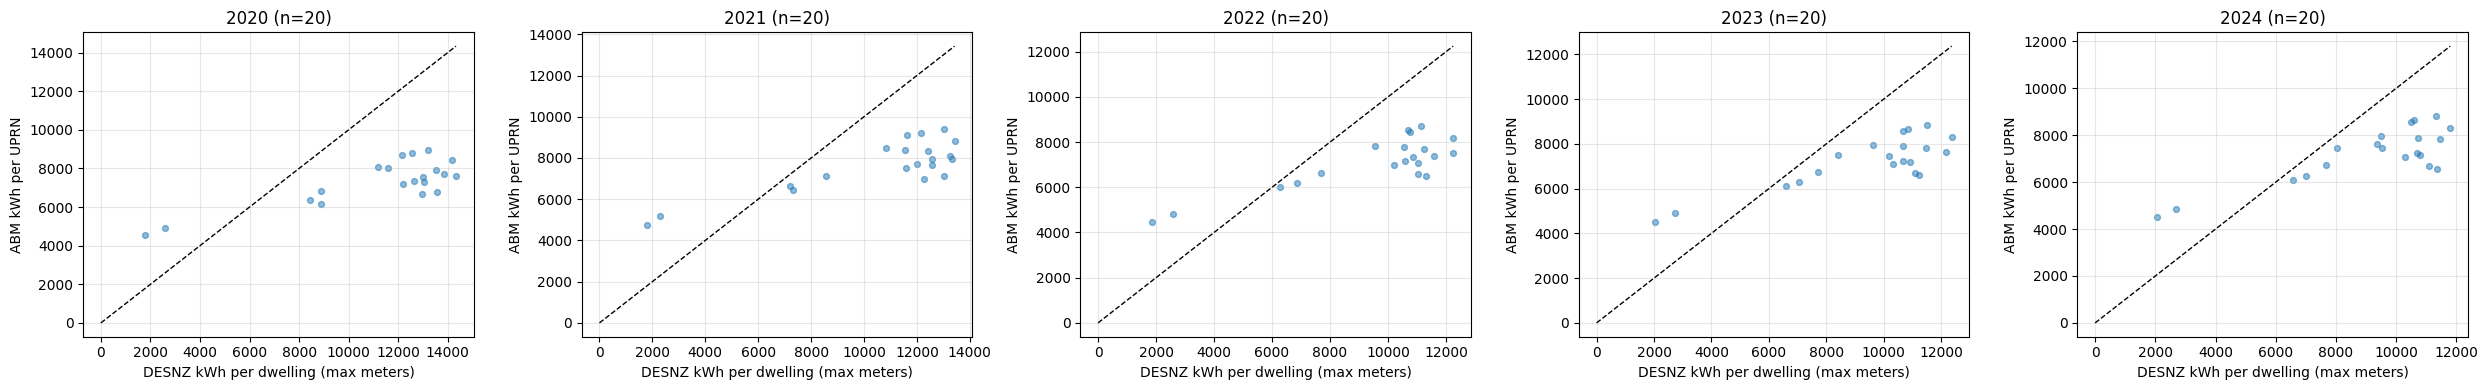

<Figure size 600x400 with 0 Axes>

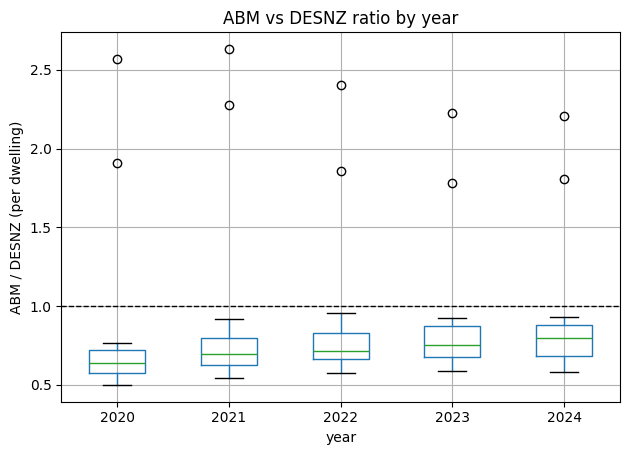

In [23]:

years_sorted = sorted(cmp['year'].unique())
fig, axes = plt.subplots(1, len(years_sorted), figsize=(5*len(years_sorted),4), sharex=False, sharey=False)
if len(years_sorted)==1:
    axes=[axes]
for ax, yr in zip(axes, years_sorted):
    sub = cmp[cmp['year']==yr]
    ax.scatter(sub['desnz_mean_kwh_per_dw'], sub['abm_kwh_per_dw'], alpha=0.5, s=18)
    mx = max(sub['desnz_mean_kwh_per_dw'].max(), sub['abm_kwh_per_dw'].max())
    ax.plot([0,mx],[0,mx],'k--',lw=1)
    ax.set_title(f"{yr} (n={len(sub)})")
    ax.set_xlabel('DESNZ kWh per dwelling (max meters)')
    ax.set_ylabel('ABM kWh per UPRN')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
cmp.boxplot(column='ratio', by='year')
plt.axhline(1.0, color='k', linestyle='--', lw=1)
plt.ylabel('ABM / DESNZ (per dwelling)')
plt.title('ABM vs DESNZ ratio by year')
plt.suptitle(''); plt.tight_layout(); plt.show()


This cell was replaced by the updated DESNZ processing pipeline (max meters denominator, preserved mean/median).

In [24]:
## Debug run: single high-ratio LSOA with agents (one month)
from household_energy.climate import ClimateField
from household_energy.model import EnergyModel

# pick target
try:
    TARGET_LSOA = hi_lsoas[0]
except Exception:
    TARGET_LSOA = cmp.sort_values('ratio', ascending=False)[LSOA_COL].iloc[0]
print(f"Target LSOA: {TARGET_LSOA}")

DEBUG_OUTDIR = Path('results_lsoa_wf') / TARGET_LSOA / f"run_debug_agents_{pd.Timestamp.utcnow():%Y%m%d}"
DEBUG_OUTDIR.mkdir(parents=True, exist_ok=True)

# filter dwellings
sub_gdf = gdf[gdf[LSOA_COL].astype(str) == TARGET_LSOA].copy()
print(f"Households in run: {len(sub_gdf):,}")

# one-month window (Jan 2023)
cf = ClimateField(CLIMATE)
start = pd.Timestamp('2023-07-01T00:00:00Z')
end = pd.Timestamp('2023-08-01T00:00:00Z')
i0 = cf.time_index_for(start)
i1 = cf.time_index_for(end)
T_hours = i1 - i0
start = pd.to_datetime(cf.times[i0], utc=True)

model = EnergyModel(
    gdf=sub_gdf,
    climate_parquet=CLIMATE,
    climate_start=start,
    local_tz='Europe/London',
    collect_agent_level=True,
    agent_collect_every=1,
)

for _ in range(T_hours):
    model.step()

mdl = model.model_dc.get_model_vars_dataframe().copy()
mdl['hour_start_utc'] = start + pd.to_timedelta(mdl.index - 1, unit='h')
mdl = mdl.set_index('hour_start_utc').iloc[1:]
mdl.to_parquet(DEBUG_OUTDIR / 'model_timeseries.parquet')

agent_df = model.agent_dc.get_agent_vars_dataframe()
agent_df.to_parquet(DEBUG_OUTDIR / 'agent_timeseries.parquet')
print('Saved agent_timeseries.parquet')
print('Outputs written to', DEBUG_OUTDIR)

# Spike analysis
agent_df = pd.read_parquet(DEBUG_OUTDIR / 'agent_timeseries.parquet').reset_index()
agent_df = agent_df[agent_df['agent_type'].str.lower() == 'household']
agent_df['month_kwh'] = agent_df.groupby('AgentID')['energy_consumption'].transform('sum')
spikes = (
    agent_df.groupby('AgentID')['energy_consumption']
        .agg(max_hour='max', mean_hour='mean', month_kwh='sum')
        .reset_index()
)
# attach features
lk_cols = ['UPRN', 'property_type', 'sap_rating', 'floor_area_m2', 'main_fuel_type', 'main_heating_system']
lk = sub_gdf[[c for c in lk_cols if c in sub_gdf.columns]].copy()
lk['UPRN'] = lk['UPRN'].astype(str)
spikes = spikes.merge(lk, left_on='AgentID', right_on='UPRN', how='left')

print('Top 30 dwellings by peak hourly kWh (Jan 2023):')
display(spikes.sort_values('max_hour', ascending=False).head(30))


Target LSOA: E01004444
Households in run: 1,615
Saved agent_timeseries.parquet
Outputs written to results_lsoa_wf/E01004444/run_debug_agents_20260210
Top 30 dwellings by peak hourly kWh (Jan 2023):


,AgentID,max_hour,mean_hour,month_kwh,UPRN,property_type,sap_rating,floor_area_m2,main_fuel_type,main_heating_system
1527,200001440571,2.328890,1.050704,782.774676,200001440571,end-terraced house,70,189.00,mains gas,boiler
388,100022567030,2.267531,0.929579,692.536046,100022567030,end-terraced house,61,185.00,mains gas,boiler
1517,200001440560,2.241937,1.012476,754.294940,200001440560,mid-terraced house,53,156.00,mains gas,boiler
1526,200001440570,2.180225,0.936795,697.912268,200001440570,end-terraced house,69,189.00,mains gas,boiler
225,100022547257,2.103852,0.958475,714.064217,100022547257,mid-terraced house,49,113.00,mains gas,boiler
...,...,...,...,...,...,...,...,...,...,...
198,100022547223,1.651111,0.714366,532.202388,100022547223,mid-terraced house,57,119.00,mains gas,boiler
233,100022547271,1.643200,0.761107,567.024362,100022547271,mid-terraced house,64,121.00,mains gas,boiler
1498,200001427727,1.632585,0.838668,624.808018,200001427727,small block of flats/dwelling converted in to ...,23,106.00,electricity,room heaters
197,100022547221,1.611724,0.759839,566.079684,100022547221,mid-terraced house,66,119.00,mains gas,boiler


In [25]:
## EPC cross-check for spiky dwellings (use raw certificates CSV)
EPC_CSV = "/Users/abeltran/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/dt/esa/sample/data/open_inputs/domestic-E09000031-Waltham-Forest/certificates.csv"

import pandas as pd
print('Loading EPC CSV...')
epc = pd.read_csv(EPC_CSV, low_memory=False)
epc.columns

Loading EPC CSV...


Index(['LMK_KEY', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY',
       'POTENTIAL_ENERGY_EFFICIENCY', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY',
       'LODGEMENT_DATE', 'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'ENERGY_CONSUMPTION_POTENTIAL', 'CO2_EMISSIONS_CURRENT',
       'CO2_EMISS_CURR_PER_FLOOR_AREA', 'CO2_EMISSIONS_POTENTIAL',
       'LIGHTING_COST_CURRENT', 'LIGHTING_COST_POTENTIAL',
       'HEATING_COST_CURRENT', 'HEATING_COST_POTENTIAL',
       'HOT_WATER_COST_CURRENT', 'HOT_WATER_COST_POTENTIAL',
       'TOTAL_FLOOR_AREA', 'ENERGY_TARIFF', 'MAINS_GAS_FLAG', 'FLOOR_LEVEL',
       'FLAT_TOP_STOREY', 'FLAT_STOREY_COUNT', 'MAIN_HEATING_CONTROLS',
       'MULTI_GLAZE_PROPORTION', 'GLAZED_TYPE', 'GLAZED_AREA',
      

In [31]:
## EPC cross-check for spiky dwellings (use raw certificates CSV)
EPC_CSV = "/Users/abeltran/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/dt/esa/sample/data/open_inputs/domestic-E09000031-Waltham-Forest/certificates.csv"

import pandas as pd
print('Loading EPC CSV...')
epc = pd.read_csv(EPC_CSV, low_memory=False)

# normalize column names
cols_lower = {c: c.lower() for c in epc.columns}
epc.rename(columns=cols_lower, inplace=True)

# UPRN as int string
uprn_series = pd.to_numeric(epc.get('uprn'), errors='coerce').astype('Int64')

# build EPC frame
E = pd.DataFrame({
    'UPRN': uprn_series.astype(str),
    'property_type': epc.get('property_type'),
    'built_form': epc.get('built_form'),
    'floor_area_m2': pd.to_numeric(epc.get('total_floor_area'), errors='coerce'),
    'sap_rating': pd.to_numeric(epc.get('current_energy_efficiency'), errors='coerce'),
    'sap_band_ord': epc.get('current_energy_rating'),
    'energy_consumption_current': pd.to_numeric(epc.get('energy_consumption_current'), errors='coerce'),
})
E['energy_cal_kwh'] = (E['energy_consumption_current'] * E['floor_area_m2']).round(1)

if 'spikes' not in globals():
    raise RuntimeError("Run the debug agent run to define 'spikes' first")
spike_ids = spikes[['AgentID']].rename(columns={'AgentID':'UPRN'})
spike_ids['UPRN'] = spike_ids['UPRN'].astype(str)

merged_epc = spike_ids.merge(E, on='UPRN', how='left')
print(f"Merged EPC rows: {len(merged_epc)}")




Loading EPC CSV...
Merged EPC rows: 2213


In [32]:
print('EPC energy_cal_kwh summary for spiky dwellings:')
print(merged_epc['energy_cal_kwh'].describe())

print('Missing energy_cal_kwh count:')
print(merged_epc['energy_cal_kwh'].isna().sum())

print('Sample merged rows:')
display(merged_epc.head())

EPC energy_cal_kwh summary for spiky dwellings:
count     2213.000000
mean     10683.594758
std       8196.786096
min        648.000000
25%       3570.000000
50%       9185.000000
75%      15136.000000
max      77182.000000
Name: energy_cal_kwh, dtype: float64
Missing energy_cal_kwh count:
0
Sample merged rows:


,UPRN,property_type,built_form,floor_area_m2,sap_rating,sap_band_ord,energy_consumption_current,energy_cal_kwh
0,100022516377,House,End-Terrace,80.0,67,D,214,17120.0
1,100022516378,House,End-Terrace,86.0,82,B,91,7826.0
2,100022516378,House,End-Terrace,86.0,83,B,87,7482.0
3,100022516378,House,End-Terrace,78.0,73,C,135,10530.0
4,100022516380,House,Mid-Terrace,88.0,70,C,178,15664.0


In [33]:
spikes

,AgentID,max_hour,mean_hour,month_kwh,UPRN,property_type,sap_rating,floor_area_m2,main_fuel_type,main_heating_system
0,100022516377,1.142658,0.632713,471.370890,100022516377,end-terraced house,67,80.00,mains gas,boiler
1,100022516378,1.164494,0.698373,520.288086,100022516378,end-terraced house,73,78.00,mains gas,boiler
2,100022516380,1.147516,0.642300,478.513486,100022516380,mid-terraced house,76,86.00,mains gas,boiler
3,100022516382,1.228695,0.695029,517.796288,100022516382,mid-terraced house,76,86.56,mains gas,boiler
4,100022516383,0.875139,0.541306,403.273024,100022516383,end-terraced house,82,74.00,mains gas,boiler
...,...,...,...,...,...,...,...,...,...,...
1610,200001454520,0.941270,0.573783,427.468605,200001454520,mid-terraced house,67,47.00,mains gas,boiler
1611,200001454614,0.628331,0.446925,332.958899,200001454614,small block of flats/dwelling converted in to ...,72,44.00,mains gas,boiler
1612,200001455887,0.785973,0.544386,405.567587,200001455887,small block of flats/dwelling converted in to ...,69,50.00,mains gas,boiler
1613,200001455888,1.065071,0.669305,498.632170,200001455888,small block of flats/dwelling converted in to ...,56,65.00,mains gas,boiler


In [34]:
from pathlib import Path

# Clean merge with EPC + HIDP socio features
spikes_clean = spikes.copy()
spikes_clean['UPRN'] = spikes_clean['UPRN'].astype(str)
merged_epc['UPRN'] = merged_epc['UPRN'].astype(str)

# socio columns from enriched gdf (after HIDP merge)
hidp_cols = [c for c in [
    'hidp','hh_n_people','hh_children','hh_income_band','hh_edu_detail',
    'dwelling_bucket','tenure','schedule_type'
] if c in gdf.columns]
gdf_socio = gdf[['UPRN'] + hidp_cols].copy() if 'UPRN' in gdf.columns else gdf[hidp_cols].copy()
if 'UPRN' in gdf_socio:
    gdf_socio['UPRN'] = gdf_socio['UPRN'].astype(str)

spikes_epc = spikes_clean.merge(merged_epc, on='UPRN', how='left', suffixes=('', '_epc'))
if hidp_cols:
    spikes_epc = spikes_epc.merge(gdf_socio, on='UPRN', how='left')

# EPC-derived hourly base (calibrated path: no multipliers)
spikes_epc['epc_hourly_base'] = spikes_epc['energy_cal_kwh'] / (365 * 24)

keep_cols = [
    'UPRN', 'max_hour', 'mean_hour', 'month_kwh',
    'energy_cal_kwh', 'energy_consumption_current', 'floor_area_m2',
    'property_type', 'built_form', 'sap_rating',
    'main_fuel_type', 'main_heating_system', 'epc_hourly_base'
] + hidp_cols
keep_cols = [c for c in keep_cols if c in spikes_epc.columns]
spikes_view = spikes_epc[keep_cols]

print('Spikes merged shape:', spikes_view.shape)
display(spikes_view.head(20))

# Save to CSV
out_csv = Path('results_lsoa_wf') / f"spikes_epc_{pd.Timestamp.utcnow():%Y%m%d%H%M%S}.csv"
spikes_view.to_csv(out_csv, index=False)
print('Saved to', out_csv)


Spikes merged shape: (2213, 21)


,UPRN,max_hour,mean_hour,month_kwh,energy_cal_kwh,energy_consumption_current,floor_area_m2,property_type,built_form,sap_rating,main_fuel_type,main_heating_system,epc_hourly_base,hidp,hh_n_people,hh_children,hh_income_band,hh_edu_detail,dwelling_bucket,tenure,schedule_type
0,100022516377,1.142658,0.632713,471.370890,17120.0,214,80.00,end-terraced house,End-Terrace,67,mains gas,boiler,1.954338,1.387411e+09,2.0,False,NaN,postgrad_or_degree,terraced_house,social_rent,dual_earner_household
1,100022516378,1.164494,0.698373,520.288086,7826.0,91,78.00,end-terraced house,End-Terrace,73,mains gas,boiler,0.893379,9.090172e+08,4.0,True,q5_highest,postgrad_or_degree,terraced_house,social_rent,single_parent_with_children
2,100022516378,1.164494,0.698373,520.288086,7482.0,87,78.00,end-terraced house,End-Terrace,73,mains gas,boiler,0.854110,9.090172e+08,4.0,True,q5_highest,postgrad_or_degree,terraced_house,social_rent,single_parent_with_children
3,100022516378,1.164494,0.698373,520.288086,10530.0,135,78.00,end-terraced house,End-Terrace,73,mains gas,boiler,1.202055,9.090172e+08,4.0,True,q5_highest,postgrad_or_degree,terraced_house,social_rent,single_parent_with_children
4,100022516380,1.147516,0.642300,478.513486,15664.0,178,86.00,mid-terraced house,Mid-Terrace,76,mains gas,boiler,1.788128,1.654855e+09,2.0,True,q3_mid,postgrad_or_degree,terraced_house,social_rent,single_parent_with_children
5,100022516380,1.147516,0.642300,478.513486,11868.0,138,86.00,mid-terraced house,Mid-Terrace,76,mains gas,boiler,1.354795,1.654855e+09,2.0,True,q3_mid,postgrad_or_degree,terraced_house,social_rent,single_parent_with_children
6,100022516382,1.228695,0.695029,517.796288,16359.8,189,86.56,mid-terraced house,Mid-Terrace,76,mains gas,boiler,1.867557,9.075076e+08,4.0,True,q3_mid,upper_further,terraced_house,social_rent,working_adult_household
7,100022516383,0.875139,0.541306,403.273024,17297.3,224,74.00,end-terraced house,End-Terrace,82,mains gas,boiler,1.974578,5.018468e+08,1.0,False,q2_low,no_qualification,terraced_house,social_rent,unemployed_or_inactive
8,100022516383,0.875139,0.541306,403.273024,12144.0,176,74.00,end-terraced house,End-Terrace,82,mains gas,boiler,1.386301,5.018468e+08,1.0,False,q2_low,no_qualification,terraced_house,social_rent,unemployed_or_inactive
9,100022516383,0.875139,0.541306,403.273024,23088.0,312,74.00,end-terraced house,End-Terrace,82,mains gas,boiler,2.635616,5.018468e+08,1.0,False,q2_low,no_qualification,terraced_house,social_rent,unemployed_or_inactive


Saved to results_lsoa_wf/spikes_epc_20260211110757.csv


In [35]:
# Multipliers / caps used by the ABM (property type & floor area)
from pathlib import Path
import yaml, numpy as np, pandas as pd
from household_energy.agent import PROPERTY_TYPE_MULTIPLIER

# 1) Property-type multipliers (used in baseline + heating slope/capacity)
print("Property-type multipliers:")
for k, v in PROPERTY_TYPE_MULTIPLIER.items():
    print(f"  {k:50s} -> {v:4.2f}")

# 2) Model power/cap defaults (pulled from code fallbacks in model.py)
model_defaults = {
    "heat_slope_area_exp": 0.6,
    "heat_slope_min": 0.0,
    "heat_slope_max": 0.10,
    "max_heat_kwh_per_hour": 20.0,
    "max_total_kwh_per_hour": 20.0,
    "max_base_kwh_per_hour": 5.0,
    "base_heat_capacity": 8.0,
    "heat_capacity_area_exp": 0.5,
    "min_heat_capacity": 4.0,
}

# If your active config overrides any of these, load them from YAML
cfg_path = Path("household_energy/config_defaults.yaml")
if cfg_path.exists():
    cfg = yaml.safe_load(cfg_path.read_text())
    m = cfg.get("model", {}) or {}
    for k in list(model_defaults):
        model_defaults[k] = m.get(k, model_defaults[k])

print("\nModel caps / scaling (active values):")
for k, v in model_defaults.items():
    print(f"  {k:25s}: {v}")

# 3) Floor-area scaling examples (for the heating slope exponent)
def area_scale(area_m2, exp=model_defaults["heat_slope_area_exp"], lo=0.6, hi=1.6):
    return float(np.clip((area_m2 / 90.0) ** exp, lo, hi))

areas = [60, 90, 120, 180, 300]
print("\nFloor-area factor examples (slope scale):")
for a in areas:
    print(f"  {a:4.0f} m² -> {area_scale(a):.3f}")


Property-type multipliers:
  mid-terraced house                                 -> 1.00
  semi-detached house                                -> 1.10
  small block of flats/dwelling converted in to flats -> 0.90
  large block of flats                               -> 0.85
  block of flats                                     -> 0.85
  end-terraced house                                 -> 1.05
  detached house                                     -> 1.20
  flat in mixed use building                         -> 0.90

Model caps / scaling (active values):
  heat_slope_area_exp      : 0.6
  heat_slope_min           : 0.0
  heat_slope_max           : 0.1
  max_heat_kwh_per_hour    : 20.0
  max_total_kwh_per_hour   : 20.0
  max_base_kwh_per_hour    : 5.0
  base_heat_capacity       : 8.0
  heat_capacity_area_exp   : 0.5
  min_heat_capacity        : 4.0

Floor-area factor examples (slope scale):
    60 m² -> 0.784
    90 m² -> 1.000
   120 m² -> 1.188
   180 m² -> 1.516
   300 m² -> 1.600



## ABM baseline/heating changes (applied 2026-01-30)

- Baseline energy now uses a fixed, meter-anchored load (0.40 kWh/h) with mild area + property-type scaling and a hard cap of 1.5 kWh/h.
- EPC-derived annuals no longer scale the baseline; structural levers (SAP, envelope, fuel) now affect only heating response.
- Property-type multipliers split: `property_type_mult_base` for baseline, `pt_heat_mult` (and `PROPERTY_TYPE_MULT_HEAT`) for heating (detached 1.20, semi 1.10, flats 0.85–0.90).
- Duty-cycle heating model retained; total hourly cap still at 20 kWh/h with per-component clip diagnostics (`base_kwh`, `heat_kwh`, `spike_kwh`, `cap_clip_*`).
- Key config knobs live in `household_energy/config_defaults.yaml` under `model:` (baseline anchor, area exponents, caps).
